## TP3 -- Florian ANDRE (ING4 Majeure Cybersécurité, groupe 1)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

# Chargement des bibliothèques de données

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
from pathlib import Path

# 1. Chargement du dataset
# Search for the dataset from the notebook's working directory and its parent
matches = list(Path.cwd().parent.rglob("people_wiki.csv"))

if not matches:
    raise FileNotFoundError(
        "people_wiki.csv was not found. Check that the dataset is downloaded."
    )

df = pd.read_csv(matches[0])

print(f"Nombre total de documents : {len(df)}")
df.head()

Nombre total de documents : 59071


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


## Prétraitement du texte

In [7]:
# Nettoyage direct des textes (passage en minuscules + suppression de la ponctuation)
df['cleaned_text'] = df['text'].astype(str).str.lower()

# Table de traduction pour enlever la ponctuation
translator = str.maketrans('', '', string.punctuation)
df['cleaned_text'] = df['cleaned_text'].apply(lambda text: text.translate(translator))

print("Exemple de texte nettoyé :")
print(df['cleaned_text'].iloc[0][:200])

Exemple de texte nettoyé :
digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his earl


## Vectorisation TF-IDF

In [8]:
# Transformation du texte en matrice numérique TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Récupération du vocabulaire (mots associés aux colonnes)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Dimension de la matrice TF-IDF : {X.shape}")

Dimension de la matrice TF-IDF : (59071, 548202)


## Comparaison des initialisations et impact de la graine aléatoire

In [9]:
k_test = 10

# Comparaison des méthodes d'initialisation (random vs k-means++)
km_random = KMeans(n_clusters=k_test, init='random', random_state=42, n_init=10).fit(X)
km_kpp = KMeans(n_clusters=k_test, init='k-means++', random_state=42, n_init=10).fit(X)

print(f"Inertie (random)    : {km_random.inertia_:.2f}")
print(f"Inertie (k-means++) : {km_kpp.inertia_:.2f}")

print("\n--- Influence de random_state (avec init='random' et n_init=1) ---")
for seed in [0, 42, 123]:
    km_seed = KMeans(n_clusters=k_test, init='random', random_state=seed, n_init=1).fit(X)
    print(f"Graine {seed:3d} | Inertie = {km_seed.inertia_:.2f}")

Inertie (random)    : 57121.48
Inertie (k-means++) : 57115.77

--- Influence de random_state (avec init='random' et n_init=1) ---
Graine   0 | Inertie = 57174.27
Graine  42 | Inertie = 57146.06
Graine 123 | Inertie = 57192.08


## Choix du nombre de clusters (Méthode du coude)

k =   2 | Inertie = 58027.02
k =  10 | Inertie = 57115.77
k =  25 | Inertie = 56377.56
k =  50 | Inertie = 55622.76
k = 100 | Inertie = 54866.12


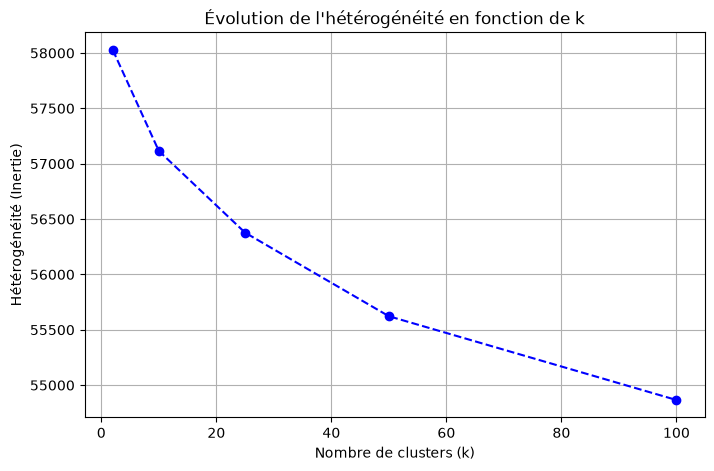

In [10]:
k_values = [2, 10, 25, 50, 100]
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    print(f"k = {k:3d} | Inertie = {km.inertia_:.2f}")

# Graphique d'évaluation
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Hétérogénéité (Inertie)')
plt.title('Évolution de l\'hétérogénéité en fonction de k')
plt.grid(True)
plt.show()

## Visualisation et interprétation des clusters ($k = 10$)

In [11]:
best_k = 10
km_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10).fit(X)
df['cluster_10'] = km_final.labels_
centroids = km_final.cluster_centers_

# Affichage des mots-clés et documents proches pour chaque cluster
for cluster_id in range(best_k):
    print(f"\n==================== CLUSTER {cluster_id} ====================")
    
    # 1. Les 10 mots les plus représentatifs du cluster
    centroid_weights = centroids[cluster_id]
    top_indices = centroid_weights.argsort()[-10:][::-1]
    top_words = feature_names[top_indices]
    print(f"Mots clés : {', '.join(top_words)}")
    
    # 2. Les 3 documents les plus proches du centroïde
    cluster_docs_indices = np.where(km_final.labels_ == cluster_id)[0]
    distances = euclidean_distances(X[cluster_docs_indices], centroids[cluster_id].reshape(1, -1)).flatten()
    closest_docs_idx = cluster_docs_indices[distances.argsort()[:3]]
    
    print("Exemples de personnalités :")
    for idx in closest_docs_idx:
        name = df.iloc[idx]['name']
        excerpt = df.iloc[idx]['text'][:120].replace('\n', ' ')
        print(f"  - {name} : \"{excerpt}...\"")


==================== CLUSTER 0 ====================
Mots clés : film, theatre, films, television, series, award, role, actor, directed, festival
Exemples de personnalités :
  - Singeetam Srinivasa Rao : "singeetam srinivasa rao born 21 september 1931 is an indian film director producer screenwriter composer singer lyricist..."
  - Shona Auerbach : "shona auerbach is a british film director and cinematographerauerbach began her career as a stills photographer she stud..."
  - Justin Edgar : "justin edgar is a british film directorborn in handsworth birmingham on 18 august 1971 edgar graduated from portsmouth u..."

==================== CLUSTER 1 ====================
Mots clés : new, book, published, university, born, radio, work, years, books, news
Exemples de personnalités :
  - Larry Woiwode : "larry alfred woiwode born october 30 1941 is an american writer who lives in north dakota where he has been the states p..."
  - Robert Fleming (author) : "robert fleming is a journalist and w